In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile as wav
from scipy.signal import windows, spectrogram, stft, istft
from scipy.signal.windows import hann
import typing

## Aid Functions:

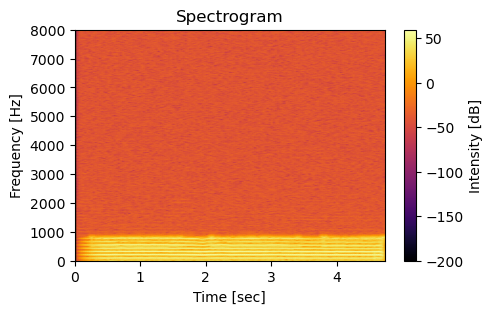

In [5]:
def plot_representation(file_path, plot_waveform=False, plot_spectogram=False, plot_linear_spectogram=False):
    """
    print the wanted representation of the .wav file in the given path

    Args:
        file_path (string): the path of the file to read and represent
        plot_waveform (bool): whether to plot the waveform of the of the audio file
        plot_spectogram (bool): whether to plot the spectogram of the of the audio file
        plot_linear_spectogram (bool): whether to plot the spectogram of the of the audio file where the magnetude is linear rather than logaritmic(Db)
    """
    sample_rate, raw_data = wav.read(file_path) # read the wav file
    sample_count = len(raw_data) # store the number of samples
    recording_length = sample_count / sample_rate
    
    if plot_waveform == True:
        time = np.linspace(0, recording_length, sample_count) # create the time x-axis for ploting.
        
        # Plot the waveform
        plt.figure(figsize=(10, 4))
        plt.plot(time, raw_data, color="green")
        plt.xlabel('Time [s]')
        plt.ylabel('Amplitude')
        plt.title('Amplitude Graph of the WAV File')
        plt.show()

    if plot_spectogram == True:
        # computing the spectogram
        frequencies, time_segments, spectogram = stft(raw_data, fs=sample_rate, nperseg=1024) 
        # Plot the spectrogram
        plt.figure(figsize=(5, 3))
        plt.pcolormesh(time_segments, frequencies, 20 * np.log10(np.abs(spectogram) + 1e-10), shading='gouraud', cmap="inferno")
        plt.ylabel('Frequency [Hz]')
        plt.xlabel('Time [sec]')
        plt.title('Spectrogram')
        plt.colorbar(label='Intensity [dB]')
        plt.show()

    if plot_linear_spectogram == True:
        # computing the spectogram
        frequencies, time_segments, spectogram = stft(raw_data, fs=sample_rate, nperseg=1024) 
        # Plot the spectrogram
        plt.figure(figsize=(5, 3))
        plt.pcolormesh(time_segments, frequencies, np.abs(spectogram), shading='gouraud', cmap="inferno")
        plt.ylabel('Frequency [Hz]')
        plt.xlabel('Time [sec]')
        plt.title('Spectrogram')
        plt.colorbar(label='Intensity [magnitude]')
        plt.show()
        
def modify_sound(file_path):
    sample_rate, raw_data = wav.read(file_path) # read the wav file
    sample_count = len(raw_data) # store the number of samples
    # computing the spectogram
    frequencies, time_segments, spectogram = stft(raw_data, fs=sample_rate, nperseg=1024) 
    freq_condition = frequencies > 840
    freq_indices = np.where(freq_condition)
    spectogram[freq_indices, :] = 0 + 0j
    _, filtered_data = istft(spectogram, fs=sample_rate)
    output_file_path = 'modifiedSoundRecordings/filtered_audio.wav'
    wav.write(output_file_path, sample_rate, np.int16(filtered_data))

# modify_sound("originalSoundRecordings/aaa + horn.wav")
plot_representation("modifiedSoundRecordings/filtered_audio.wav", plot_waveform=False, plot_spectogram=True, plot_linear_spectogram=False)

In [3]:
def plot_representation(file_path, plot_waveform=False, plot_spectogram=False, plot_linear_spectogram=False):
    """
    print the wanted representation of the .wav file in the given path

    Args:
        file_path (string): the path of the file to read and represent
        plot_waveform (bool): whether to plot the waveform of the of the audio file
        plot_spectogram (bool): whether to plot the spectogram of the of the audio file
        plot_linear_spectogram (bool): whether to plot the spectogram of the of the audio file where the magnetude is linear rather than logaritmic(Db)
    """
    sample_rate, raw_data = wav.read(file_path) # read the wav file
    plot_representation(raw_data, sample_rate, plot_waveform=plot_waveform,
                        plot_spectogram=plot_spectogram, plot_linear_spectogram=plot_linear_spectogram)

def plot_representation(raw_data, sample_rate, plot_waveform=False, plot_spectogram=False, plot_linear_spectogram=False):
    sample_count = len(raw_data) # store the number of samples
    recording_length = sample_count / sample_rate
    
    if plot_waveform == True:
        time = np.linspace(0, recording_length, sample_count) # create the time x-axis for ploting.
        
        # Plot the waveform
        plt.figure(figsize=(10, 4))
        plt.plot(time, raw_data, color="green")
        plt.xlabel('Time [s]')
        plt.ylabel('Amplitude')
        plt.title('Amplitude Graph of the WAV File')
        plt.show()

    if plot_spectogram == True:
        # computing the spectogram
        frequencies, time_segments, spectogram = stft(raw_data, fs=sample_rate, nperseg=1024) 
        # Plot the spectrogram
        plt.figure(figsize=(5, 3))
        plt.pcolormesh(time_segments, frequencies, 20 * np.log10(np.abs(spectogram) + 1e-10), shading='gouraud', cmap="inferno")
        plt.ylabel('Frequency [Hz]')
        plt.xlabel('Time [sec]')
        plt.title('Spectrogram')
        plt.colorbar(label='Intensity [dB]')
        plt.show()

    if plot_linear_spectogram == True:
        # computing the spectogram
        frequencies, time_segments, spectogram = stft(raw_data, fs=sample_rate, nperseg=1024) 
        # Plot the spectrogram
        plt.figure(figsize=(5, 3))
        plt.pcolormesh(time_segments, frequencies, np.abs(spectogram), shading='gouraud', cmap="inferno")
        plt.ylabel('Frequency [Hz]')
        plt.xlabel('Time [sec]')
        plt.title('Spectrogram')
        plt.colorbar(label='Intensity [magnitude]')
        plt.show()
        
def modify_sound(file_path):
    sample_rate, raw_data = wav.read(file_path) # read the wav file
    sample_count = len(raw_data) # store the number of samples
    # computing the spectogram
    frequencies, time_segments, spectogram = stft(raw_data, fs=sample_rate, nperseg=1024) 
    freq_condition = frequencies > 840
    freq_indices = np.where(freq_condition)
    spectogram[freq_indices, :] = 0 + 0j
    _, filtered_data = istft(spectogram, fs=sample_rate)
    output_file_path = 'modifiedSoundRecordings/filtered_audio.wav'
    wav.write(output_file_path, sample_rate, np.int16(filtered_data))

# modify_sound("originalSoundRecordings/aaa + horn.wav")
plot_representation("modifiedSoundRecordings/filtered_audio.wav", plot_waveform=False, plot_spectogram=True, plot_linear_spectogram=False)

TypeError: plot_representation() missing 1 required positional argument: 'sample_rate'

# Expermenting

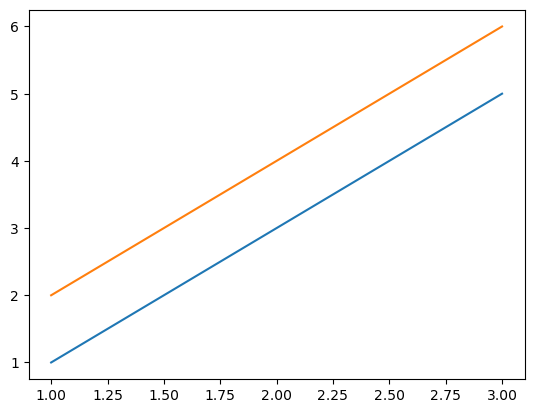

In [84]:
x = [1, 2, 3]
y = np.array([[1, 2], [3, 4], [5, 6]])
plt.plot(x, y)

In [ ]:
file_path = "originalSoundRecordings/aaa.wav"
# plot it's waveform:
sample_rate, raw_data = wav.read(file_path)

print(type(raw_data))
print(raw_data.shape)
# plt.plot(raw_data)

sample_count = len(raw_data)
rec_len = sample_count / sample_rate
time = np.linspace(0, rec_len, num=sample_count)
print(len(time))
plt.plot(time, raw_data)

sample_rate:16000, sample_count:77760


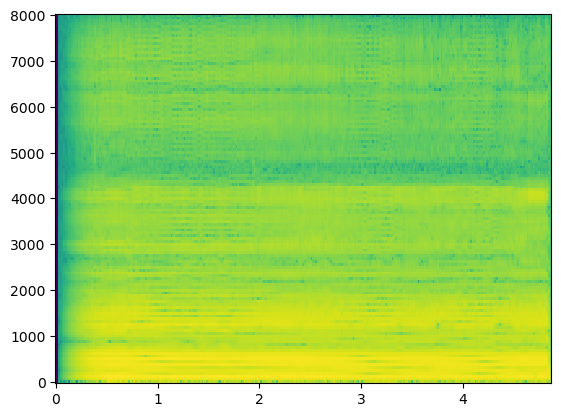

In [164]:
file_path = "originalSoundRecordings/aaa.wav"
# plot it's spectogram
sample_rate, raw_data = wav.read(file_path)
sample_count = len(raw_data)
print(f'sample_rate:{sample_rate}, sample_count:{sample_count}')
f,t,STFT = stft(raw_data, sample_rate, noverlap=0)
plt.pcolormesh(t,f,20*np.log(np.abs(STFT)+0.00000001))

## Didactic Analesis

### Recording Of Speach Without Noise

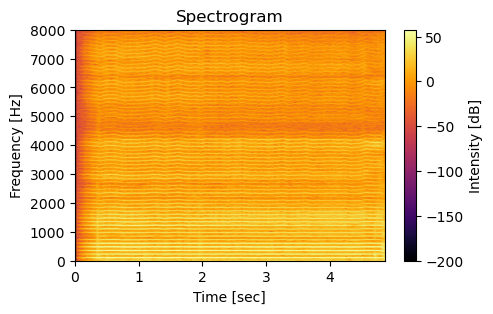

In [22]:
print_representation("originalSoundRecordings/aaa.wav", plot_waveform=False, plot_spectogram=True , plot_linear_spectogram=False)

### Recording Of Speach Without Noise

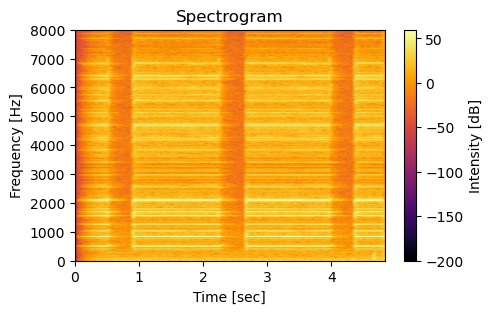

In [24]:
print_representation("originalSoundRecordings/car horn.wav", plot_waveform=False, plot_spectogram=True , plot_linear_spectogram=False)

### Recording Of Speach With Noise

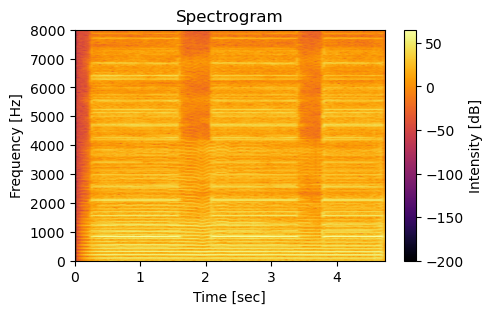

In [26]:
print_representation("originalSoundRecordings/aaa + horn.wav", plot_waveform=False, plot_spectogram=True, plot_linear_spectogram=False)

## Analysing white noise

In [28]:
wn_sample_rate, wn_raw_data = wav.read("originalSoundRecordings/car horn.wav")
wn_sample_count = len(wn_raw_data)
print(wn_sample_count)
wn_recording_length = wn_sample_count / wn_sample_rate

76960


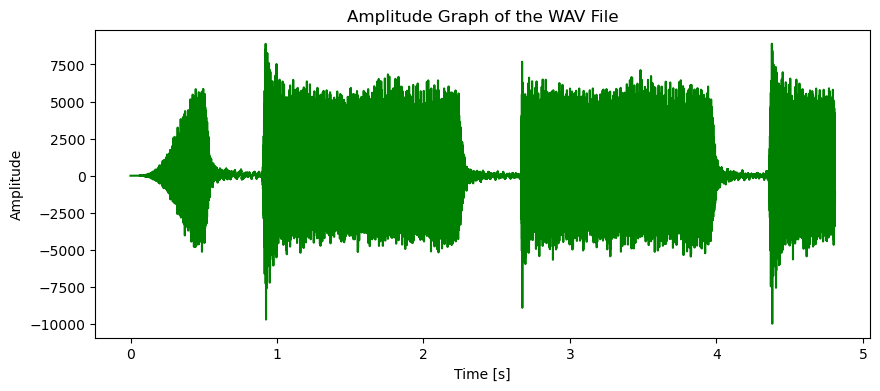

In [29]:
wn_time = np.linspace(0, wn_recording_length, wn_sample_count)

# Plot the waveform
plt.figure(figsize=(10, 4))
plt.plot(wn_time, wn_raw_data, color="green")
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
#plt.xlim([start_time, end_time])
plt.title('Amplitude Graph of the WAV File')
plt.show()

In [30]:
wn_frequencies, wn_time_segments, wn_spectogram = stft(wn_raw_data, fs=wn_sample_rate, nperseg=1024,noverlap=0)

In [31]:
print(wn_frequencies.shape)
print(wn_frequencies[-5:])

(513,)
[7937.5   7953.125 7968.75  7984.375 8000.   ]


In [32]:
print(wn_time_segments.shape)
print(wn_time_segments[:5])

(77,)
[0.    0.064 0.128 0.192 0.256]


In [33]:
print(wn_spectogram.shape)
print(wn_spectogram[0][1])

(513, 77)
(0.0042882077+0j)


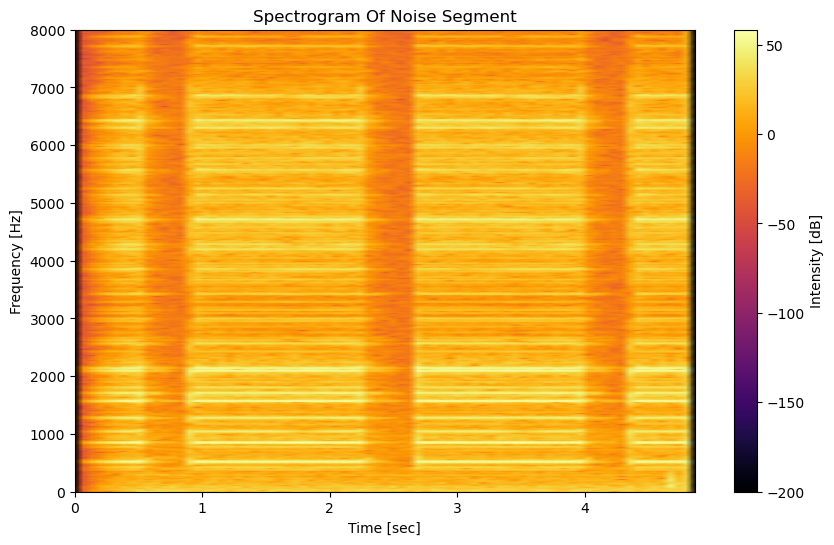

In [34]:
# Plot the spectrogram
plt.figure(figsize=(10, 6))
plt.pcolormesh(wn_time_segments, wn_frequencies, 20 * np.log10(np.abs(wn_spectogram) + 1e-10), shading='gouraud', cmap="inferno")
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.title('Spectrogram Of Noise Segment')
plt.colorbar(label='Intensity [dB]')
plt.show()

In [35]:
frequencies, time_segments, spectogram = stft(raw_data, fs=sample_rate, nperseg=1024)

NameError: name 'raw_data' is not defined

In [ ]:
# Plot the spectrogram
plt.figure(figsize=(10, 6))
plt.pcolormesh(time_segments, frequencies, 20 * np.log10(np.abs(spectogram) + 1e-10), shading='gouraud', cmap="inferno")
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.title('Spectrogram Of Speech Segment')
plt.colorbar(label='Intensity [dB]')
plt.show()

In [ ]:
nn_sample_rate, nn_raw_data = wav.read("1-5_no_noise.wav")
nn_sample_count = len(nn_raw_data)
nn_recording_length = nn_sample_count / nn_sample_rate

In [ ]:
nn_frequencies, nn_time_segments, nn_spectogram = stft(nn_raw_data, fs=nn_sample_rate, nperseg=1024)

In [ ]:
# Plot the spectrogram
plt.figure(figsize=(10, 6))
plt.pcolormesh(nn_time_segments, nn_frequencies, 20 * np.log10(np.abs(nn_spectogram) + 1e-10), shading='gouraud', cmap="inferno")
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.title('Spectrogram Of Noise-Free Speech Segment')
plt.colorbar(label='Intensity [dB]')
plt.show()

In [ ]:
spectogram_clean = spectogram - wn_spectogram[:,:228]

In [ ]:
# Plot the spectrogram
plt.figure(figsize=(10, 6))
plt.pcolormesh(time_segments, frequencies, 20 * np.log10(np.abs(spectogram_clean) + 1e-10), shading='gouraud', cmap="inferno")
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.title('Spectrogram Of Difference')
plt.colorbar(label='Intensity [dB]')
plt.show()

## Attempts in noise reduction

#### Magnitude subtraction on entire frequencies of signal

In [ ]:
fft_signal = np.fft.fft(raw_data)

In [ ]:
fft_signal[0]

In [ ]:
assert(len(fft_signal) == sample_count)

In [ ]:
frequencies = np.fft.fftfreq(sample_count, d=1/sample_rate)
magnitudes = np.abs(fft_signal)
phases = np.angle(fft_signal)

In [ ]:
assert(len(frequencies) == len(magnitudes) == len(fft_signal))

In [ ]:
# Plot the magnitude spectrum
plt.figure(figsize=(10, 6))
plt.plot(frequencies[:sample_count // 2], magnitudes[:sample_count // 2], color="red", label="with noise")
plt.legend()
plt.title("Magnitude Spectrum of the Signal")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.show()

In [ ]:
frequencies_abs = np.abs(frequencies)
frequency_cond = (frequencies_abs <= 250) | (frequencies_abs >= 1000)    
frequency_indices = np.where(frequency_cond)

In [ ]:
frequency_indices

In [ ]:
fft_modified = fft_signal
fft_modified[frequency_indices] = 0 * 0j

In [ ]:
# Plot the magnitude spectrum
# plt.figure(figsize=(10, 6))
# plt.plot(frequencies[:sample_count // 2], magnitudes_modified[:sample_count // 2])
# plt.title("Magnitude Spectrum of the Signal")
# plt.xlabel("Frequency (Hz)")
# plt.ylabel("Magnitude")
# plt.show()

In [ ]:
modified_signal = np.fft.ifft(fft_modified).real
modified_signal_sample_count = len(modified_signal)
modified_signal_time = modified_signal_sample_count / sample_rate

In [ ]:
time_modified = np.linspace(0, modified_signal_time, modified_signal_sample_count)

# Plot the waveform
plt.figure(figsize=(10, 4))
plt.plot(time_modified, modified_signal, color="green")
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
#plt.xlim([0, 0.5])
plt.title('Amplitude Graph of the WAV File(After trimming)')
plt.show()

In [ ]:
wav.write("1-5_cleaned.wav", sample_rate, modified_signal.astype(np.int16))

#### Simple windowing and STFT using built-in libraries(Magnitude subtraction)

In [ ]:
noise_segment = raw_data[:int(sample_rate * 0.5)]
frequencies_noise_segment, times_noise_segment, noise_spectrogram = stft(noise_segment, fs=sample_rate, nperseg=2024, noverlap=None)

In [ ]:
noise_spectrogram.shape

In [ ]:
print(f"Number of frequencies: {noise_spectrogram.shape[0]}\nNumber of frames: {noise_spectrogram.shape[1]}")

In [ ]:
noise_spectogram_magnitudes = np.abs(noise_spectrogram)
noise_spectogram_log_magnitudes = 20 * np.log10(noise_spectogram_magnitudes + np.finfo(float).eps) 
noise_magnitude_average = np.mean(noise_spectogram_magnitudes, axis=1)

In [ ]:
len(noise_magnitude_average)

In [ ]:
# Plot the spectrogram
plt.figure(figsize=(10, 6))
plt.pcolormesh(times_noise_segment, frequencies_noise_segment, noise_spectogram_log_magnitudes, shading='gouraud', cmap="inferno")
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.title('Spectrogram Of Noise Segment')
plt.colorbar(label='Intensity [dB]')
plt.show()

In [ ]:
frequencies_signal, times_signal, noisy_spectrogram_signal = stft(new_data, fs=sample_rate, nperseg=2024, noverlap=None)

In [ ]:
clean_spectrogram = np.zeros_like(noisy_spectrogram_signal)

In [ ]:
num_of_windows = noisy_spectrogram_signal.shape[1]

In [ ]:
print(f"Number of signal windows: {num_of_windows}")

In [ ]:
log_magnitude_noisy_signal = 20 * np.log10(np.abs(noisy_spectrogram_signal) + np.finfo(float).eps)

In [ ]:
# Plot the spectrogram
plt.figure(figsize=(10, 6))
plt.pcolormesh(times_signal, frequencies_signal, log_magnitude_noisy_signal, shading='gouraud', cmap="inferno")
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.title('Spectrogram Of Noise Segment')
plt.colorbar(label='Intensity [dB]')
plt.show()

In [ ]:
#Spectral subtraction of each frame
for i in range(num_of_windows):
    noisy_magnitude = np.abs(noisy_spectrogram_signal[:, i])
    clean_magnitude = np.maximum(noisy_magnitude - noise_magnitude_average, 0)  # Subtract and apply non-negative constraint
    clean_spectrogram[:, i] = clean_magnitude * np.exp(1j * np.angle(noisy_spectrogram_signal[:, i]))  # Combine with original phase

In [ ]:
log_magnitude_clean_signal = 20 * np.log10(np.abs(clean_spectrogram) + np.finfo(float).eps)

In [ ]:
# Convert the clean spectrogram back to the time domain
_, clean_signal = istft(clean_spectrogram, fs=sample_rate)

# Save the cleaned audio signal
wav.write('cleaned_audio.wav', sample_rate, clean_signal.astype(np.int16))

In [ ]:
time = np.linspace(0, len(clean_signal) / sample_rate, len(clean_signal))

# Plot the waveform
plt.figure(figsize=(10, 4))
plt.plot(time, clean_signal, color="green")
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
#plt.xlim([start_time, end_time])
plt.title('Amplitude Graph of the WAV File')
plt.show()

In [ ]:
plt.figure(figsize=(10, 5))
plt.subplot(2, 1, 1)
plt.title('Noisy Signal Spectrogram')
plt.pcolormesh(times_signal, frequencies_signal, log_magnitude_noisy_signal, shading='gouraud', cmap="inferno")
plt.colorbar()
plt.subplot(2, 1, 2)
plt.title('Clean Signal Spectrogram')
plt.pcolormesh(times_signal, frequencies_signal, log_magnitude_clean_signal, shading='gouraud', cmap="inferno")
plt.colorbar()
plt.tight_layout()
plt.show()

#### Simple windowing and STFT using built-in libraries(Magnitude subtraction)

In [ ]:
window_size = 1024

In [ ]:
frequencies_signal, times_signal, dft_noisy_signal = stft(raw_data, fs=sample_rate, nperseg=window_size)

In [ ]:
times_signal

In [ ]:
dft_noisy_signal.shape

In [ ]:
magnitude_noisy_signal = np.abs(dft_noisy_signal)
phase_noisy_signal = np.angle(dft_noisy_signal)
db_magnitude_noisy_signal = 20 * np.log10(magnitude_noisy_signal + 1e-10)

In [ ]:
white_noise_db = np.mean(db_magnitude_noisy_signal[:, :10], axis = 1, keepdims=True)
white_noise_magnitude = 10**(white_noise_db / 20)

In [ ]:
# Noise suppression: Subtract noise estimate in dB
magnitude_enhanced_db = db_magnitude_noisy_signal - white_noise_db
magnitude_enhanced_db = np.maximum(magnitude_enhanced_db, 0)

In [ ]:
magnitude_enhanced = 10**(magnitude_enhanced_db / 20)

In [ ]:
dft_enchanced = magnitude_enhanced * np.exp(1j * phase_noisy_signal)

In [ ]:
_, y_enhanced = istft(dft_enchanced, fs=sample_rate, nperseg=window_size)

In [ ]:
y_enhanced = np.int16(y_enhanced / np.max(np.abs(y_enhanced)) * 32767)

In [ ]:
wav.write('cleaned_audio_db.wav', sample_rate, y_enhanced)

In [ ]:
# Plotting the spectrograms
plt.figure(figsize=(12, 6))

# Noisy signal spectrogram
plt.subplot(2, 1, 1)
plt.pcolormesh(times_signal, frequencies_signal, db_magnitude_noisy_signal, shading='gouraud')
plt.title('Noisy Signal')
plt.colorbar(label='dB')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')

# Enhanced signal spectrogram
plt.subplot(2, 1, 2)
plt.pcolormesh(times_signal, frequencies_signal, 20 * np.log10(magnitude_enhanced + 1e-10), shading='gouraud')
plt.title('Enhanced Signal')
plt.colorbar(label='dB')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')

plt.tight_layout()
plt.show()

#### Manual windowing

In [ ]:
reconstructed_signal_simple_windowing = np.zeros(new_data_sample_count)

In [ ]:
window_size = int(0.8 * sample_rate)
overlap_size = int(0 * sample_rate)
step_size = window_size - overlap_size

In [ ]:
windows = np.split(new_data, np.arange(window_size, new_data_sample_count, window_size))

In [ ]:
windows_windowed = []

In [ ]:
start_index = 0

for window_index in range(len(windows)):
    window_size = len(windows[window_index])
    windows_windowed.append(windows[window_index] * hann(window_size))
    end_index = start_index + window_size

    reconstructed_signal_simple_windowing[start_index:end_index] += windows_windowed[-1]
    start_index = end_index
        

In [ ]:
reconstructed_signal_simple_windowing

In [ ]:
time_new_data = np.linspace(0, new_data_recording_time, new_data_sample_count)

# Plot the waveform
plt.figure(figsize=(10, 4))
plt.plot(time_new_data, reconstructed_signal_simple_windowing, color="green")
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
#plt.xlim([0, 0.5])
plt.title('Amplitude Graph of the WAV File(After trimming)')
plt.show()

In [ ]:
wav.write("1-5_attempt_1.wav", sample_rate, reconstructed_signal_simple_windowing.astype(np.int16))

In [ ]:
dft = np.fft.fft(new_data)

# Compute the frequency axis for plotting
frequencies = np.fft.fftfreq(new_data_sample_count, d=1/sample_rate)[:new_data_sample_count//2]
magnitude = np.abs(dft[:new_data_sample_count // 2])
magnitude_squared = np.power(magnitude, 2)

## More complex background cleaning attempt